### Part 2 of the thesis
Analyzing Top Mean-REs Detections

Evaluating WT7

In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import training_lib as tl
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from torch import nn
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple
import numpy as np
import os
from glob import glob

# %matplotlib widget

In [2]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)

{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [3]:
print(f"test start:{cfg_part2.test_start_time}\n"
      f"test end:  {cfg_part2.test_end_time}")

test start:2020-05-01 04:10:00
test end:  2022-12-31 23:50:00


In [4]:
theta = p2.load_threshold_table()

   WT_ID    k        mu     sigma  threshold   tp   fn     fp  precision  \
0      1  1.0  0.013096  0.029094    0.04219  7.0  1.0  236.0   0.028807   

   recall        f1  FAR_per_day  latency_mean  
0   0.875  0.055777     1.594595    111.714286  


In [5]:
test_eval_file = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv")) [0]
test_eval_df = pd.read_csv(test_eval_file)

display(test_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,0.094487,0.020666,0.021166,0.002876,0.011175,...,0.002781,0.001968,0.000169,0.004524,0.000044,0.000239,0.012340,0.000073,0.000367,0.236192
1,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,0.147881,0.003152,0.005707,0.000037,0.000812,...,0.000992,0.014479,0.004077,0.037727,0.014320,0.001727,0.014470,0.003942,0.013449,0.237053
2,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,0.000007,0.002139,0.001538,0.000092,0.000897,...,0.000284,0.000529,0.000318,0.003309,0.000072,0.000651,0.005969,0.000130,0.000011,0.000130
3,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,0.035099,0.013446,0.022986,0.000044,0.008692,...,0.000418,0.002332,0.004244,0.015442,0.001185,0.018634,0.051762,0.007190,0.001146,0.000083
4,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,0.043485,0.000567,0.001858,0.005117,0.000530,...,0.000232,0.000188,0.000374,0.001174,0.001621,0.000152,0.001344,0.002955,0.003236,0.000237


In [6]:
files = glob(os.path.join(ic.PATH_PART2_DETECTIONS, "part2_dets_gdays_1.csv"))[0]
print(files)


C:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\Penmanshiel\processed_data\signal_imputation\part2\detections\part2_dets_gdays_1.csv


In [7]:
selected_detections = pd.read_csv(files)
selected_detections = selected_detections.sort_values(by=[ic.MEAN_LOSS_PER_SAMPLE], ascending=False)
display(selected_detections)

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1641412800000000012,2022-01-05 20:00:00,12,8.343366,185.189804,0.161642,0.084029,1.625053e-01,0.079211,0.356811,...,0.650402,0.431948,0.001236,0.565393,0.660837,0.163096,8.497208e-02,120.361855,1.656347,0.255011
1,1638304800000000015,2021-11-30 20:40:00,15,7.308167,221.789429,0.082104,0.026219,6.360460e-02,0.034467,0.003375,...,0.022054,0.199845,0.003873,0.000185,0.000030,0.156328,1.263669e-02,50.305603,1.514961,0.013934
2,1607461200000000007,2020-12-08 21:00:00,7,6.686425,160.447952,0.044653,0.153851,1.492391e-01,0.127547,0.174829,...,0.071026,0.218922,0.000388,0.000864,0.006635,0.188975,1.725636e-02,88.545135,1.338055,0.049147
3,1637131800000000006,2021-11-17 06:50:00,6,2.243517,40.572876,0.155494,0.000003,1.098039e-03,0.002843,0.003309,...,0.084316,0.032460,0.073693,0.005464,0.013264,0.001733,3.281211e-03,40.832470,2.697380,0.001447
4,1634922600000000007,2021-10-22 17:10:00,7,2.033795,0.183905,0.197341,0.481804,9.396648e-01,0.270806,2.538486,...,2.449968,0.219454,0.052992,2.129529,2.982091,0.363277,4.962097e+00,2.100800,1.624950,0.387149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4246,1617589800000000004,2021-04-05 02:30:00,4,0.042208,0.002412,0.000017,0.137855,3.717969e-02,0.122224,0.002799,...,0.074507,0.000918,0.043558,0.004149,0.023565,0.041169,1.635947e-03,0.066539,0.001831,0.000074
4247,1645484400000000007,2022-02-21 23:00:00,7,0.042206,0.008672,0.005798,0.032461,4.771565e-02,0.163364,0.001536,...,0.085110,0.032859,0.037879,0.033694,0.025425,0.035040,4.156611e-08,0.005208,0.000825,0.001113
4248,1650322200000000001,2022-04-18 22:50:00,1,0.042205,0.001316,0.081905,0.000207,2.132603e-06,0.200481,0.000008,...,0.118608,0.000172,0.000290,0.006912,0.000034,0.083352,8.568014e-02,0.000172,0.000727,0.000001
4249,1648477800000000012,2022-03-28 14:30:00,12,0.042204,0.103115,0.001169,0.082308,1.145668e-01,0.152458,0.062794,...,0.050217,0.042002,0.010394,0.048317,0.045872,0.037363,2.688017e-03,0.070663,0.005789,0.001347


In [8]:

windows_df = p2.build_detection_windows(det_df=selected_detections, window_days=7)

display(windows_df.head(10))

selected_detections[ic.TS_COL] = pd.to_datetime(selected_detections[ic.TS_COL])
windows_df[ic.TS_COL] = pd.to_datetime(windows_df[ic.TS_COL])
windows_df["window_start"] = pd.to_datetime(windows_df["window_start"])
windows_df["window_end"] = pd.to_datetime(windows_df["window_end"])

windows_df = selected_detections.merge(
    windows_df,
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)
display(windows_df.head())

,WT_ID,Date and time,window_start,window_end
0,12,2022-01-05 20:00:00,2021-12-29 20:00:00,2022-01-12 20:00:00
1,15,2021-11-30 20:40:00,2021-11-23 20:40:00,2021-12-07 20:40:00
2,7,2020-12-08 21:00:00,2020-12-01 21:00:00,2020-12-15 21:00:00
3,6,2021-11-17 06:50:00,2021-11-10 06:50:00,2021-11-24 06:50:00
4,7,2021-10-22 17:10:00,2021-10-15 17:10:00,2021-10-29 17:10:00
5,10,2020-08-28 17:40:00,2020-08-21 17:40:00,2020-09-04 17:40:00
6,4,2021-12-02 01:40:00,2021-11-25 01:40:00,2021-12-09 01:40:00
7,10,2020-12-29 04:40:00,2020-12-22 04:40:00,2021-01-05 04:40:00
8,10,2022-02-10 06:50:00,2022-02-03 06:50:00,2022-02-17 06:50:00
9,10,2022-12-20 03:50:00,2022-12-13 03:50:00,2022-12-27 03:50:00


,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°),window_start,window_end
0,1641412800000000012,2022-01-05 20:00:00,12,8.343366,185.189804,0.161642,0.084029,0.162505,0.079211,0.356811,...,0.001236,0.565393,0.660837,0.163096,0.084972,120.361855,1.656347,0.255011,2021-12-29 20:00:00,2022-01-12 20:00:00
1,1638304800000000015,2021-11-30 20:40:00,15,7.308167,221.789429,0.082104,0.026219,0.063605,0.034467,0.003375,...,0.003873,0.000185,0.000030,0.156328,0.012637,50.305603,1.514961,0.013934,2021-11-23 20:40:00,2021-12-07 20:40:00
2,1607461200000000007,2020-12-08 21:00:00,7,6.686425,160.447952,0.044653,0.153851,0.149239,0.127547,0.174829,...,0.000388,0.000864,0.006635,0.188975,0.017256,88.545135,1.338055,0.049147,2020-12-01 21:00:00,2020-12-15 21:00:00
3,1637131800000000006,2021-11-17 06:50:00,6,2.243517,40.572876,0.155494,0.000003,0.001098,0.002843,0.003309,...,0.073693,0.005464,0.013264,0.001733,0.003281,40.832470,2.697380,0.001447,2021-11-10 06:50:00,2021-11-24 06:50:00
4,1634922600000000007,2021-10-22 17:10:00,7,2.033795,0.183905,0.197341,0.481804,0.939665,0.270806,2.538486,...,0.052992,2.129529,2.982091,0.363277,4.962097,2.100800,1.624950,0.387149,2021-10-15 17:10:00,2021-10-29 17:10:00


In [9]:

wt = 12
date = "2022-01-05 20:00:00"
wt_windows = windows_df[(windows_df[ic.WT_ID]== wt) & (windows_df[ic.TS_COL] == date)]
anomaly_spans_wt = [(row["window_start"], row["window_end"]) for _,row in wt_windows.iterrows()]
anomaly_spans_wt = sorted(anomaly_spans_wt, key=lambda span: span[0])
min_ts = anomaly_spans_wt[0][0]
max_ts = anomaly_spans_wt[-1][1]

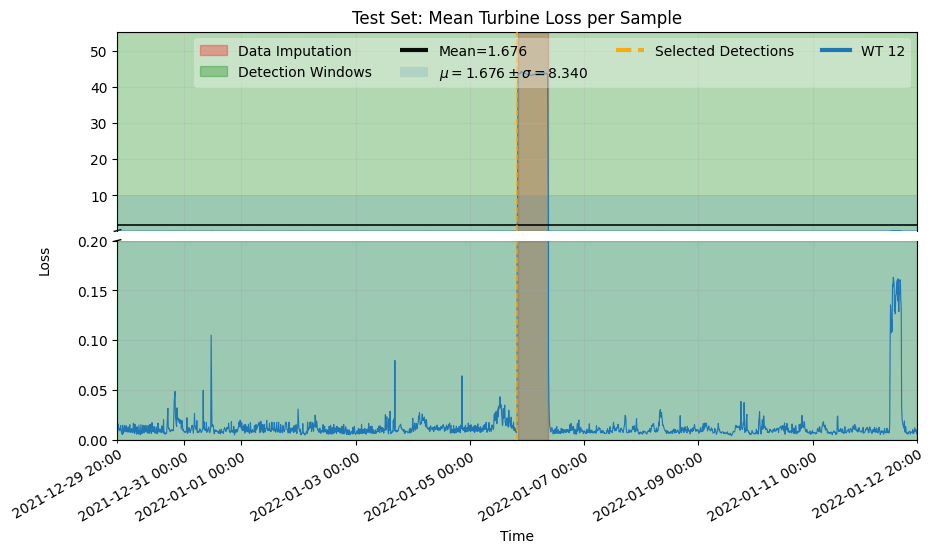

In [10]:
pp.print_loss(test_eval_df,
              dpi=300,
              y_limits=((0,0.2),(0.2,100)),
              title="Test Set: Mean Turbine Loss per Sample",
              wt_id= [wt],
              ts_range=(min_ts, max_ts),
              anomaly_spans=anomaly_spans_wt,
              #mark_threshold=theta,
              anom_span_label="Detection Windows",
              detection_ts=[date],
              figsize=(10,6),
              save_filename="p2_top_re_mean_loss_1.png",
              impute_label="Data Imputation"
              )

### Filter Top N Signals with highest RE

In [11]:
top_signals_wt = p2.get_top_sigs_for_detections(
    eval_df=p2.drop_imputations(test_eval_df),
    selected_detections=selected_detections[(selected_detections[ic.WT_ID]==wt ) & (selected_detections[ic.TS_COL]==date)],
    wt_id=wt,
    top_n_signals=3
)

print(top_signals_wt)

[(Timestamp('2022-01-05 20:00:00'), ['RE_Ambient temperature (converter) (°C)', 'RE_Transformer cell temperature (°C)', 'RE_Transformer temperature (°C)'])]


In [12]:
cols = [ic.MEAN_LOSS_PER_SAMPLE]+top_signals_wt[0][1]
print(cols)
sd_filter = selected_detections[[ic.TS_COL, ic.WT_ID]+ cols]
sd_filter[cols] = np.floor(sd_filter[cols]*100)/100
sd_filter = sd_filter.iloc[[0]]
sd_filter = sd_filter.rename(columns={ic.MEAN_LOSS_PER_SAMPLE: "MSE Loss"})
ltx = sd_filter.to_latex(index=False, escape=True, float_format="%.2f")
with open(ic.PATH_PRINTS/"p2_1_wt12_loss.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

display(sd_filter)

['Mean Loss per Sample', 'RE_Ambient temperature (converter) (°C)', 'RE_Transformer cell temperature (°C)', 'RE_Transformer temperature (°C)']


C:\Users\admin\AppData\Local\Temp\ipykernel_31204\4200436837.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sd_filter[cols] = np.floor(sd_filter[cols]*100)/100


,Date and time,WT_ID,MSE Loss,RE_Ambient temperature (converter) (°C),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C)
0,2022-01-05 20:00:00,12,8.34,185.18,120.36,1.65


In [13]:
print(len(anomaly_spans_wt))
print(anomaly_spans_wt)
print(len(top_signals_wt))
print(top_signals_wt)

1
[(Timestamp('2021-12-29 20:00:00'), Timestamp('2022-01-12 20:00:00'))]
1
[(Timestamp('2022-01-05 20:00:00'), ['RE_Ambient temperature (converter) (°C)', 'RE_Transformer cell temperature (°C)', 'RE_Transformer temperature (°C)'])]


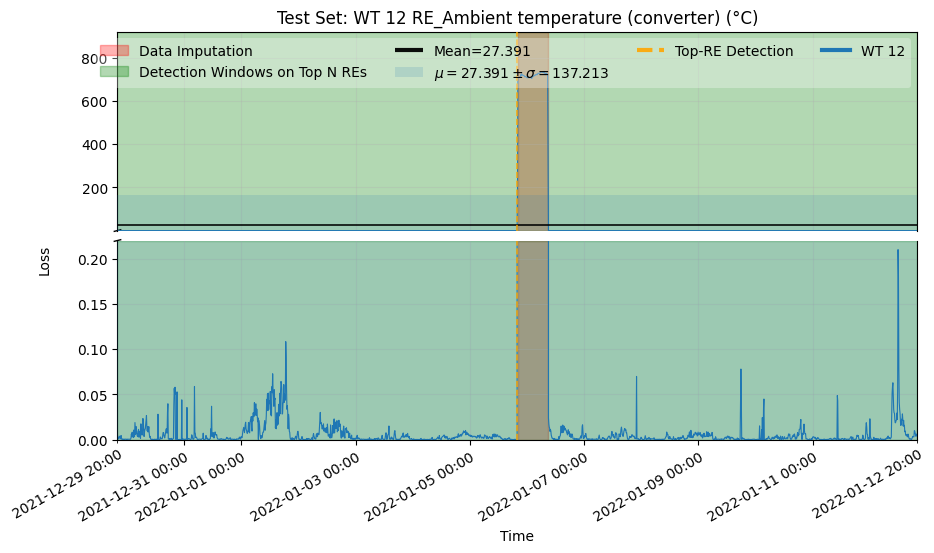

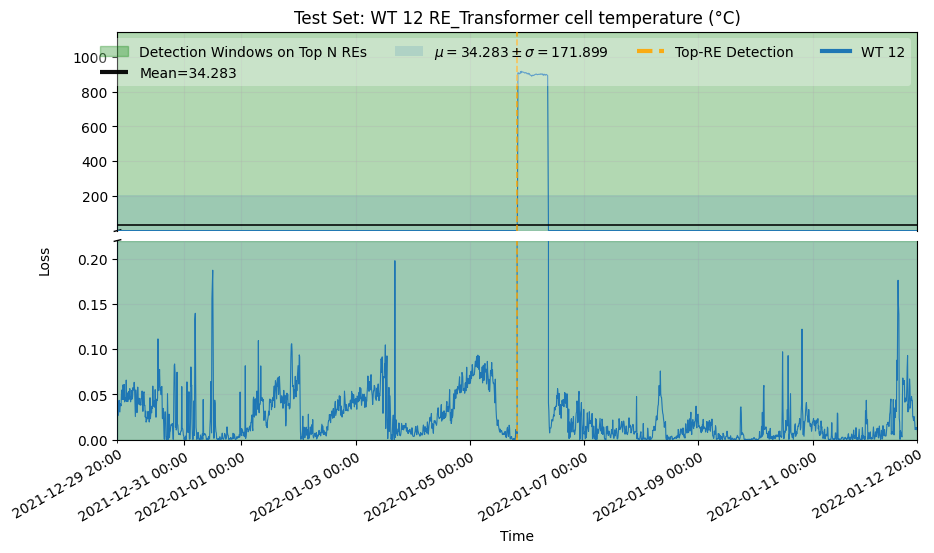

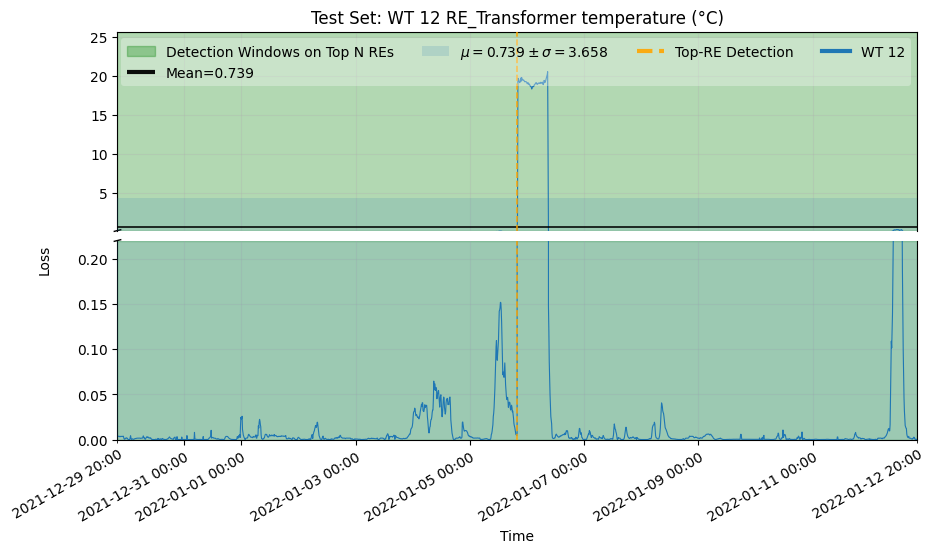

In [14]:
for idx,(ts,sig_list) in enumerate(top_signals_wt):
    for sig in sig_list:
        pp.print_loss(test_eval_df,
                    dpi=300,
                    y_limits=((0,0.22),(0.22,800)),
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=sig,
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=[anomaly_spans_wt[idx]],
                    mark_threshold=None,
                    anom_span_label="Detection Windows on Top N REs",
                    detection_ts=[ts],
                    detection_label="Top-RE Detection",
                    figsize=(10,6),
                    save_filename=f"p2_top_signals_1_{sig}.png",
                    impute_label="Data Imputation"
                    )

In [15]:
top_sigs_no_prefix_wt = [(ts, sig[3:]) for sig in sig_list  for (ts,sig_list) in top_signals_wt]
print(top_sigs_no_prefix_wt)

[(Timestamp('2022-01-05 20:00:00'), 'Ambient temperature (converter) (°C)'), (Timestamp('2022-01-05 20:00:00'), 'Transformer cell temperature (°C)'), (Timestamp('2022-01-05 20:00:00'), 'Transformer temperature (°C)')]


In [16]:
for (ts,sig) in top_sigs_no_prefix_wt:
    print(sig[:-5])

Ambient temperature (converter)
Transformer cell temperature
Transformer temperature


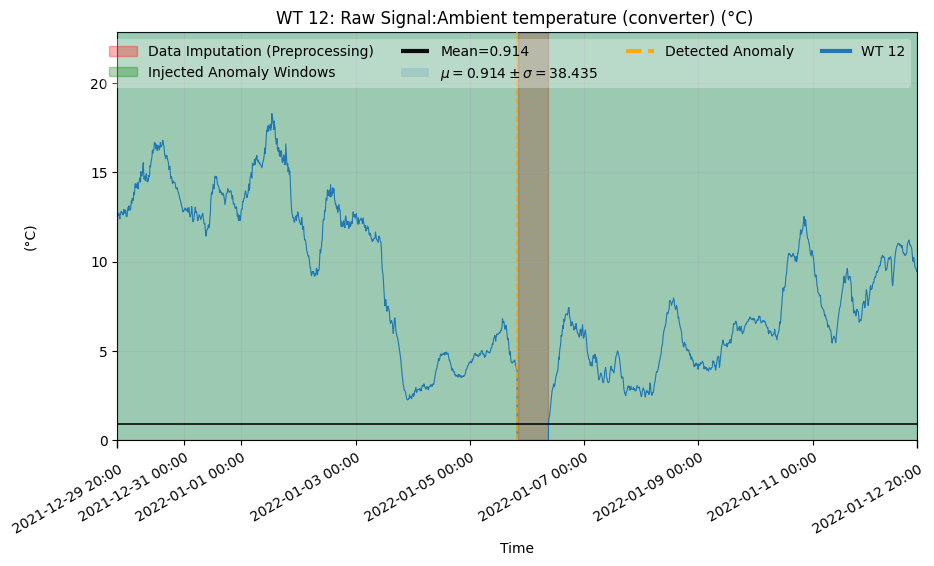

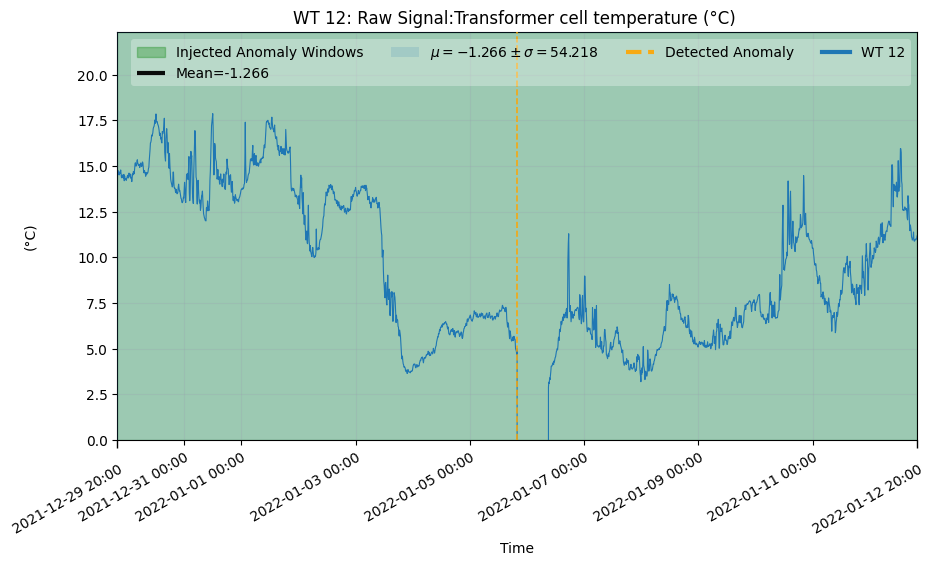

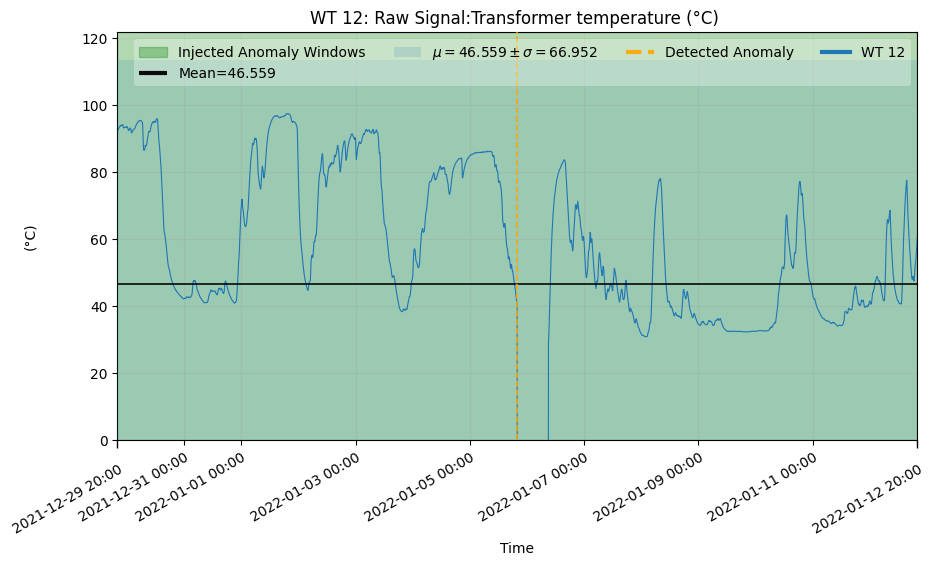

In [17]:
fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
wt_df = pd.read_csv(next(iter(fp)))

for (ts,sig) in top_sigs_no_prefix_wt:
    pp.print_loss(wt_df, 
                  values=sig,
                  title=f"WT {wt}: Raw Signal:{sig} ",
                  wt_id=[wt],
                  ts_range= (min_ts, max_ts),
                  anomaly_spans=anomaly_spans_wt,
                  detection_label="Detected Anomaly",
                  detection_ts= [ts],
                  y_label = sig[-4:],
                  figsize=(10,6),
                  save_filename=f"p2_top_re_raw_signal_1_{sig[:-5]}")



### Power Curve 

In [18]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [19]:
test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wind_col = "Wind speed (m/s)"
power_col = "Power (kW)"

imputed_files = sorted(Path(ic.PATH_IMPUTED).glob("*.csv"))

wt_farm : list[pd.DataFrame] = []


wt_farm_df = pd.read_csv(ic.PATH_PART2_WT_FARM /  "wt_farm_pc_df.csv")
wt_farm_df = wt_farm_df.sort_values([ic.WT_ID, ic.TS_COL])
wt_farm_df.head()
wt_farm_df[ic.TS_COL] = pd.to_datetime(wt_farm_df[ic.TS_COL])

In [20]:
df_det_keys = selected_detections[[ic.WT_ID, ic.TS_COL]].copy()

df_det_points = df_det_keys.merge(
    wt_farm_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,12,2022-01-05 20:00:00,6.341438,230.972735
1,15,2021-11-30 20:40:00,5.614177,182.038048
2,7,2020-12-08 21:00:00,2.360587,-1.277555
3,6,2021-11-17 06:50:00,6.780597,337.755948
4,7,2021-10-22 17:10:00,1.064987,-0.909158


c:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:992: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t_num = t.view("int64").to_numpy()


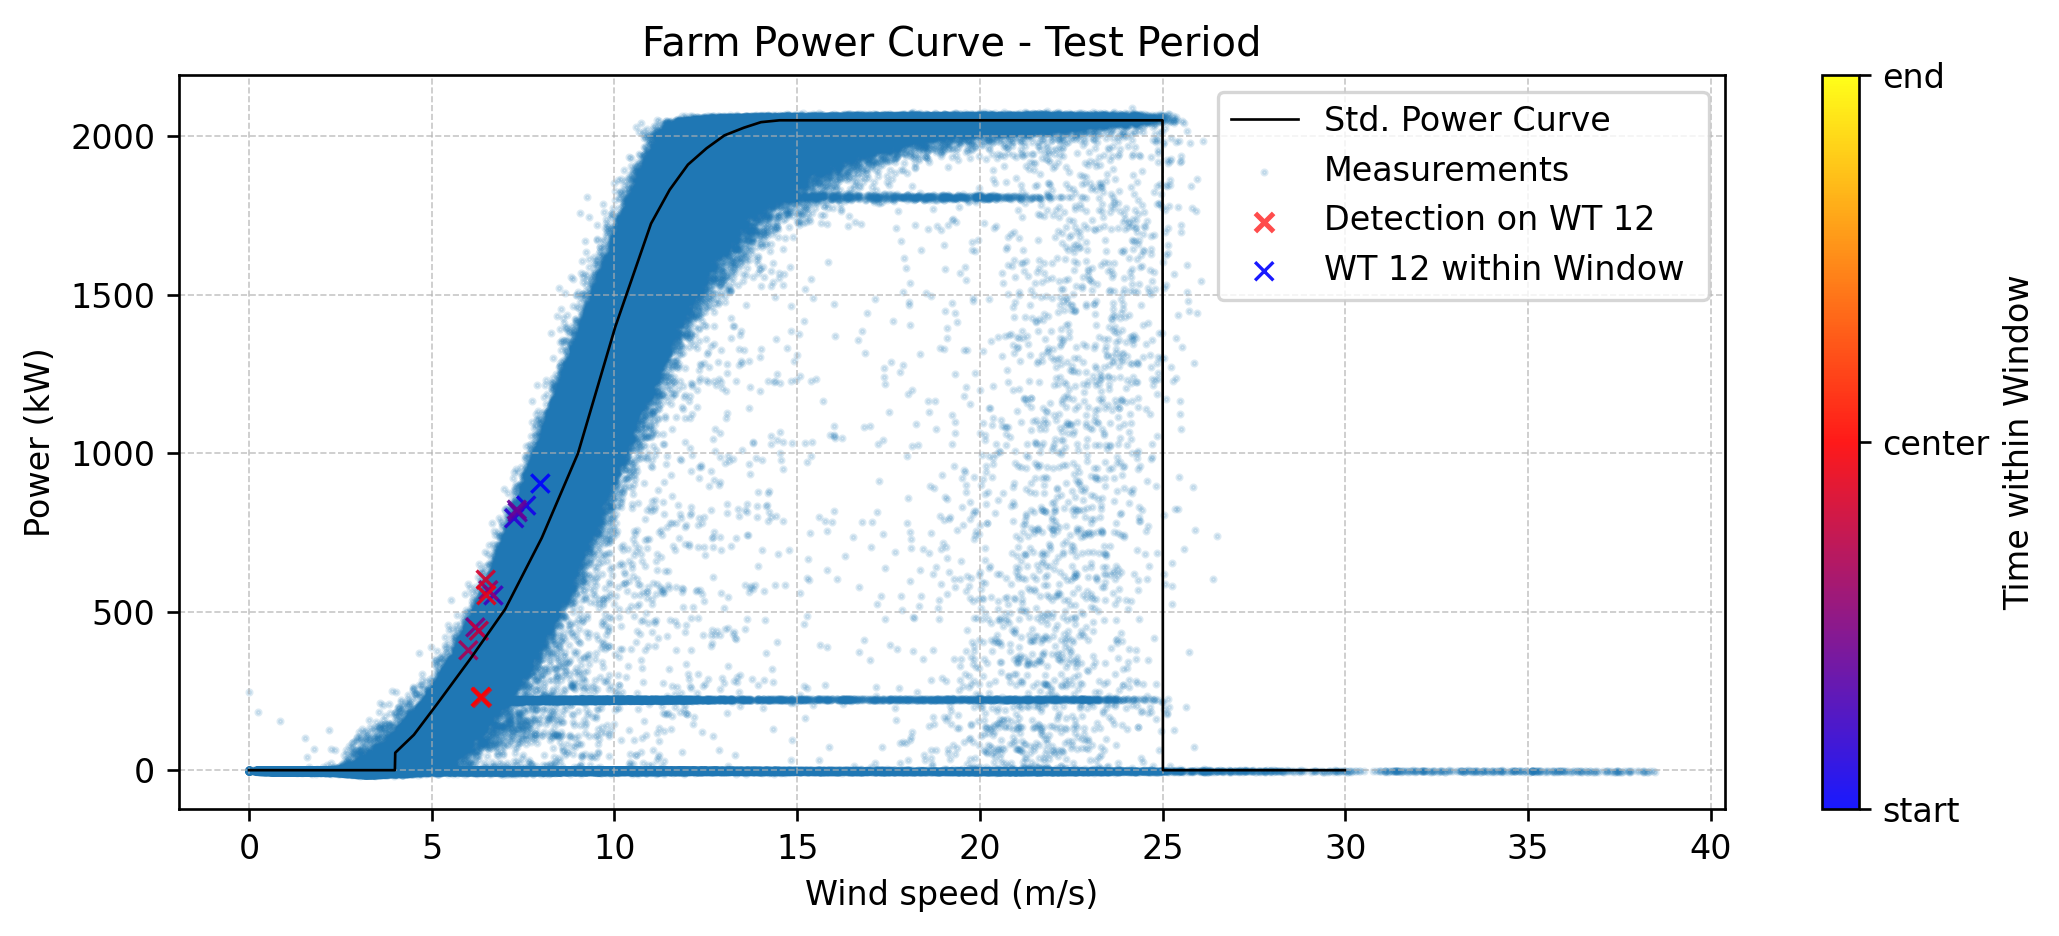

In [21]:
pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_df, pc=False),
                    df_detections=df_det_points[(df_det_points[ic.WT_ID]== wt) & (df_det_points[ic.TS_COL]==date )],
                    detections_label=f"Detection on WT {wt}",
                    highlight_wt=wt,
                    highlight_ts_range=(pd.to_datetime(date)-pd.Timedelta(hours=2), pd.to_datetime(date)+pd.Timedelta(hours=2)),
                    alpha_det=0.7,
                    fig_size=(9,4),
                    save_dir=Path(ic.PATH_PRINTS),
                    file_name="p2_top_re_1_pc.png"
                    )

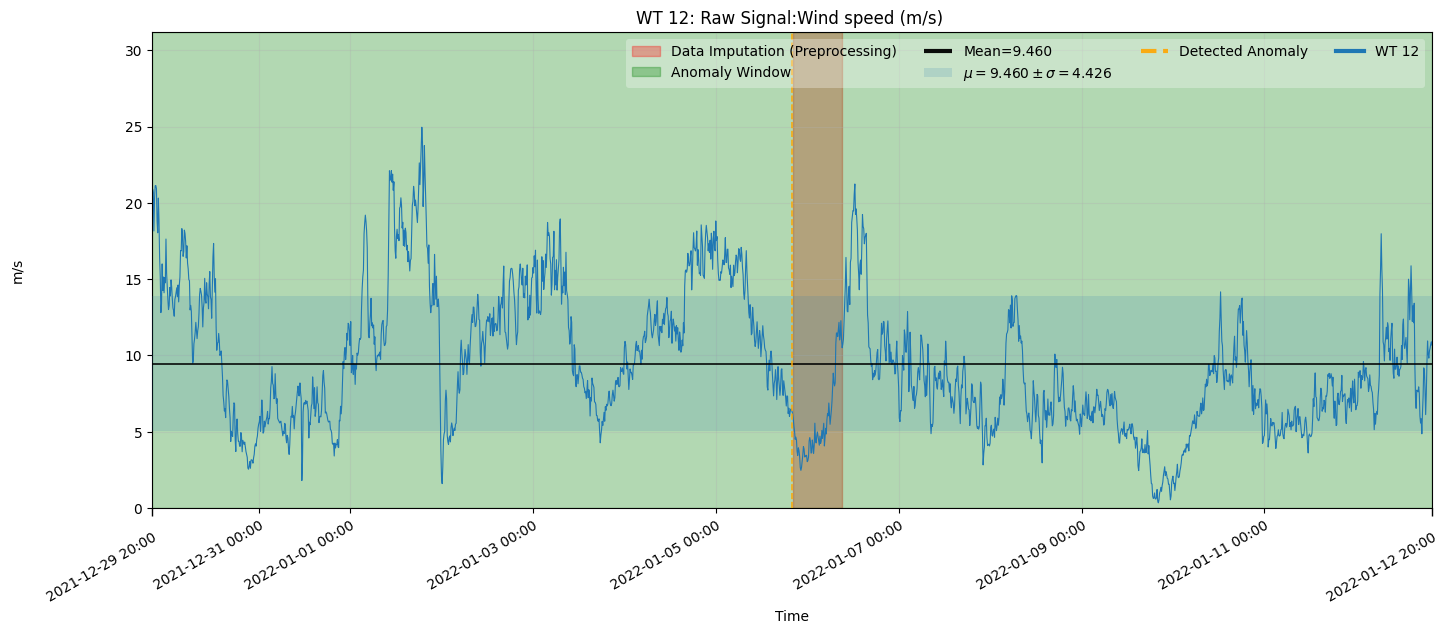

In [22]:
pp.print_loss(wt_df, 
                  values=wind_col,
                  title=f"WT {wt}: Raw Signal:{wind_col} ",
                  ts_range= (min_ts, max_ts),
                  anomaly_spans=anomaly_spans_wt,
                  detection_label="Detected Anomaly",
                  detection_ts= [ts],
                  y_label = wind_col[-4:-1],
                  anom_span_label="Anomaly Window")

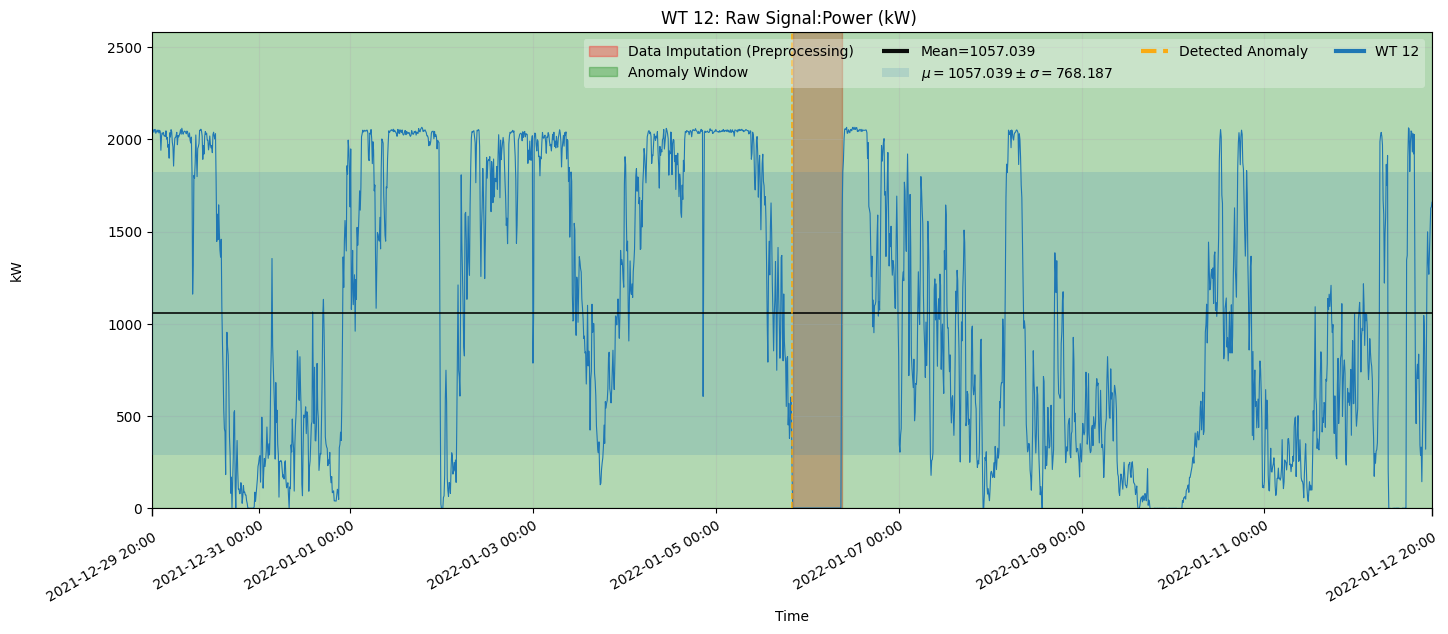

In [23]:
pp.print_loss(wt_df, 
                  values=power_col,
                  title=f"WT {wt}: Raw Signal:{power_col} ",
                  ts_range= (min_ts, max_ts),
                  anomaly_spans=anomaly_spans_wt,
                  detection_label="Detected Anomaly",
                  detection_ts= [ts],
                  y_label = power_col[-3:-1],
                  anom_span_label="Anomaly Window",
                  save_filename="p2_1_raw_power.png")

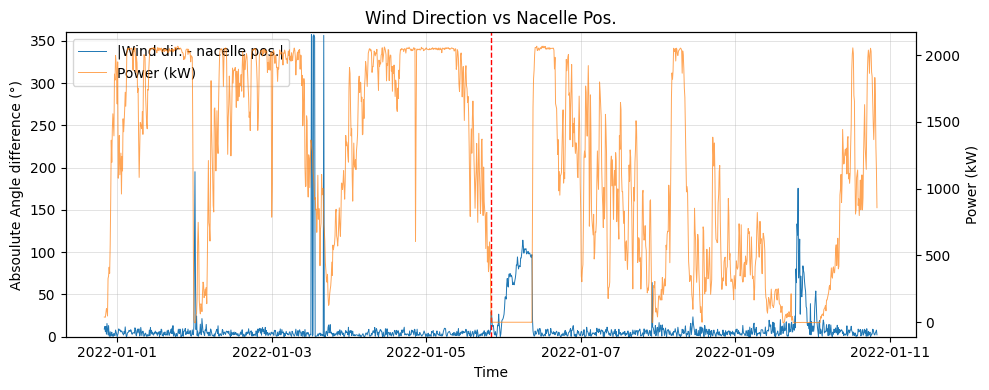

<Axes: title={'center': 'Wind Direction vs Nacelle Pos.'}, xlabel='Time', ylabel='Absoulute Angle difference (°)'>

In [24]:
pp.plot_wind_vs_nacelle(df=wt_df,
                        ts_mark=pd.to_datetime(ts),
                        ts_range=(ts-pd.Timedelta(days=5), ts+pd.Timedelta(days=5)),
                        title="Wind Direction vs Nacelle Pos.",
                        save_filename="p2_1_wind_dir_nacelle_pos.png")

In [25]:
status_logs = pd.read_csv(ic.PATH_PENMANSHIEL / "Status_Logs_Complete_ID_12.csv")
status_logs["Timestamp start"] = pd.to_datetime(status_logs["Timestamp start"], errors="coerce")
status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")

In [26]:
display(status_logs.head())

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
0,2016-07-02 16:25:34,2016-07-05 12:00:32,67:34:58,Stop,5600,Overload hydraulic pump,NaN,Electrical error (24),Forced outage,12,NaN,NaN
1,2016-07-02 16:25:35,2016-07-02 16:26:16,00:00:41,Informational,3547,Overfrequency,NaN,Warnings (27),NaN,12,NaN,NaN
2,2016-07-02 16:25:35,2016-07-02 16:27:57,00:02:22,Warning,3875,Overload transf. fan inlet air,NaN,Warnings (27),NaN,12,NaN,NaN
3,2016-07-02 16:25:35,2016-07-02 16:26:42,00:01:07,Warning,2650,Overload generator fan 2,NaN,Warnings (27),Forced outage,12,NaN,NaN
4,2016-07-02 16:25:35,2016-07-02 16:26:42,00:01:07,Warning,2655,Overload generator fan 3,NaN,Warnings (27),Forced outage,12,NaN,NaN


In [27]:
detection_ts = pd.to_datetime(date)

In [28]:
filter = status_logs[( detection_ts >= status_logs["Timestamp start"] ) & (detection_ts <= status_logs["Timestamp end"] )]

display(filter)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
37745,2022-01-02 03:54:54,2022-01-06 09:00:03,101:05:09,Warning,4607,Heating/fan base box faulty,NaN,Warnings (27),NaN,12,NaN,NaN


In [29]:
delta = pd.Timedelta(hours=3)
det_start = detection_ts - delta
det_end = detection_ts + delta

In [30]:
filter = status_logs[(status_logs["Timestamp start"] <= det_end) & (status_logs["Timestamp end"] >= det_start)]
display(filter)
print(detection_ts)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
37745,2022-01-02 03:54:54,2022-01-06 09:00:03,101:05:09,Warning,4607,Heating/fan base box faulty,NaN,Warnings (27),NaN,12,NaN,NaN
37786,2022-01-05 20:06:24,2022-01-06 09:01:32,12:55:08,Stop,3750,Grid measurement error,NaN,Electrical error (24),Out of Electrical Specification,12,09 (Int) Fault,NaN
37791,2022-01-05 20:06:26,2022-01-06 08:57:45,12:51:19,Warning,3870,Overload transformer fan outlet air,NaN,Warnings (27),Full Performance,12,NaN,NaN
37792,2022-01-05 20:06:27,2022-01-06 08:58:10,12:51:43,Warning,3220,Reduced power converter,NaN,Warnings (27),NaN,12,NaN,NaN
37793,2022-01-05 20:06:31,2022-01-06 09:00:03,12:53:32,Warning,3205,PT100 converter inlet temperature defect,NaN,Warnings (27),NaN,12,NaN,NaN
37794,2022-01-05 20:06:31,2022-01-06 09:00:03,12:53:32,Warning,4600,PT100 base box temp. defect,NaN,Warnings (27),NaN,12,NaN,NaN
37795,2022-01-05 20:06:56,2022-01-06 08:58:10,12:51:14,Warning,3160,Cable overload,NaN,Warnings (27),NaN,12,NaN,NaN
37796,2022-01-05 21:06:26,2022-01-06 09:00:09,11:53:43,Warning,2125,Timeout brake closed,NaN,Warnings (27),NaN,12,NaN,NaN


2022-01-05 20:00:00


In [31]:
ltx = filter.to_latex(index=False, escape=True)
with open(ic.PATH_PRINTS/"p2_1_status_logs.tex", "w", encoding="utf-8") as f:
    f.write(ltx)